In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tarfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, RocCurveDisplay
import gc

# Настройка GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [ ]:
import os

!pip install git+https://github.com/KindXiaoming/pykan.git --quiet

print("Установка завершена.")

  Preparing metadata (setup.py) ... done
Установка завершена.


In [ ]:
df_1 = pd.read_excel('20251213_cycle_sample_1.xlsx', sheet_name='record')
df_2 = pd.read_excel('20251213_cycle_sample_2.xlsx', sheet_name='record')
df_1 = df_1[df_1['Step Type'] == 'CC DChg']
df_2 = df_2[df_2['Step Type'] == 'CC DChg']
df_1

,DataPoint,Step Type,Time,Total Time,Current(A),Voltage(V),Capacity(Ah),Energy(Wh),Date,Power(W)
5193,5194,CC DChg,00:00:00,01:35:48,-0.1997,4.1517,0.0000,0.0000,2025-12-12 19:17:46,-0.8293
5194,5195,CC DChg,00:00:01,01:35:49,-0.2001,4.1248,0.0001,0.0002,2025-12-12 19:17:47,-0.8252
5195,5196,CC DChg,00:00:02,01:35:50,-0.2000,4.1229,0.0001,0.0005,2025-12-12 19:17:48,-0.8244
5196,5197,CC DChg,00:00:03,01:35:51,-0.2000,4.1217,0.0002,0.0007,2025-12-12 19:17:49,-0.8244
5197,5198,CC DChg,00:00:04,01:35:52,-0.2000,4.1204,0.0002,0.0009,2025-12-12 19:17:50,-0.8240
...,...,...,...,...,...,...,...,...,...,...
149195,149196,CC DChg,00:11:03,44:21:40,-0.1999,3.0145,0.0368,0.1246,2025-12-14 14:03:40,-0.6026
149196,149197,CC DChg,00:11:04,44:21:41,-0.1999,3.0108,0.0369,0.1248,2025-12-14 14:03:41,-0.6019
149197,149198,CC DChg,00:11:05,44:21:42,-0.1999,3.0069,0.0369,0.1250,2025-12-14 14:03:42,-0.6012
149198,149199,CC DChg,00:11:06,44:21:43,-0.2000,3.0033,0.0370,0.1251,2025-12-14 14:03:43,-0.6006


Загружено 800 точек  C ∈ [0.0102, 0.4985]  I ∈ [0.1998, 0.2002]  V ∈ [3.3803, 4.0711]
После отсечения 2% хвостов: 768 точек, C ∈ [0.0175, 0.4912]

⚠  I ≈ const (0.1998..0.2002 А,  σ = 0.06 мА).
   Член −R·I неотличим от константы E₀. Учим V(C), арх [1, 3, 1].
checkpoint directory created: ./model
saving model version 0.0

--- Стадия 1: Adam warm-up (grid=5) ---


| train_loss: 1.31e-02 | test_loss: 1.14e-02 | reg: 1.15e+01 | : 100%|█| 400/400 [00:05<00:00, 71.73


saving model version 0.1

--- Стадия 2: LBFGS polish (grid=5, без L1) ---


| train_loss: 1.97e-03 | test_loss: 2.20e-03 | reg: 1.20e+01 | : 100%|█| 50/50 [00:10<00:00,  4.95it


saving model version 0.2
Сохранил kan_structure.png

--- Стадия 3: auto_symbolic (узкая физ-библиотека) ---
fixing (0,0,0) with x, r2=0.9436129331588745, c=1
For (0,0,1) the best fit was x, but r^2 = 0.5788934826850891 and this is lower than 0.9. This edge was omitted, keep training or try a different threshold.
fixing (0,0,2) with x, r2=0.9182741045951843, c=1
fixing (1,0,0) with x, r2=0.9862485527992249, c=1
fixing (1,1,0) with exp, r2=0.997559130191803, c=2
fixing (1,2,0) with x, r2=0.9691375494003296, c=1
saving model version 0.3

--- Стадия 4: финальная подстройка коэффициентов (Adam) ---


...

saving model version 0.4

Формула KAN в нормированных координатах:
                                                                               ↪
-1.39644042178779⋅x₁ + 1.51502172595909⋅(5.7053599357605⋅x₁ + 6.09616041183472 ↪

↪  -0.882479709237501                    
↪ )                   - 0.264901885463855

Формула KAN в исходных координатах (C в А·ч, V в В):
                                                                               ↪
-0.853951704106795⋅C + 0.219433609963865⋅(24.0884945567258⋅C - 0.0307481786684 ↪

↪     -0.882479709237501                   
↪ 818)                   + 3.93091064213981

LaTeX:
    - 0.853951704106795 C + \frac{0.219433609963865}{\left(24.0884945567258 C - 0.0307481786684818\right)^{0.882479709237501}} + 3.93091064213981

Plan A (auto_symbolic): RMSE = 8.44 мВ, max|Δ| = 60.81 мВ

 PLAN B: fix_symbolic  →  структура  log + log + exp
checkpoint directory created: ./model
saving model version 0.0

Plan B / 1: Adam warm-up — даём сплайнам разогреть

| train_loss: 7.61e-03 | test_loss: 5.85e-03 | reg: 1.10e+01 | : 100%|█| 300/300 [00:03<00:00, 81.16


saving model version 0.1

Plan B / 2: fix_symbolic — навязываем Шепардовскую структуру
r2 is 0.9776313900947571
saving model version 0.2
r2 is 0.8226981163024902
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.3
r2 is 0.9764973521232605
saving model version 0.4
r2 is 0.7940460443496704
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.5
Best value at boundary.
r2 is 0.709643542766571
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.6
Best value at boundary.
r2 is 0.9767788052558899
saving model version 0.7

Plan B / 3: Adam дообучает аффинные параметры внутри log/exp/x


| train_loss: 1.91e-01 | test_loss: 1.80e-01 | reg: 0.00e+00 | : 100%|█| 400/400 [00:07<00:00, 55.78


saving model version 0.8

--- Формула Plan B в нормированных координатах ---
                    3.67988133430481⋅x₁                                        ↪
0.0188090657296476⋅ℯ                    + 2.60334211508252⋅log(8.5893478393554 ↪

↪                                                                              ↪
↪ 7 - 4.4887490272522⋅x₁) - 1.55399872864949⋅log(0.795770943164825⋅x₁ + 2.7387 ↪

↪                               
↪ 6476287842) - 4.00995045661436

--- Формула Plan B в исходных координатах (V в В, C в А·ч) ---
                     15.5367588528808⋅C                                        ↪
5.23621659179544e-5⋅ℯ                   + 0.377064400130556⋅log(13.40975448947 ↪

↪                                                                              ↪
↪ 83 - 18.9518641640371⋅C) - 0.225078984059416⋅log(3.35980976637038⋅C + 1.8841 ↪

↪                               
↪ 9714880211) + 3.17128047326378

LaTeX Plan B:
    5.23621659179544 \cdot 10^{-5} e^{15.5367588528808 C} + 

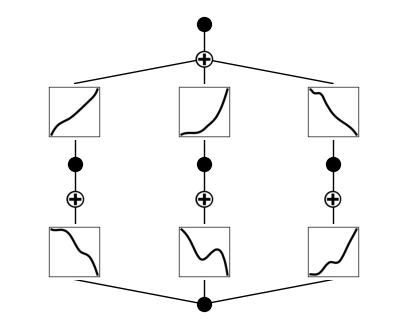

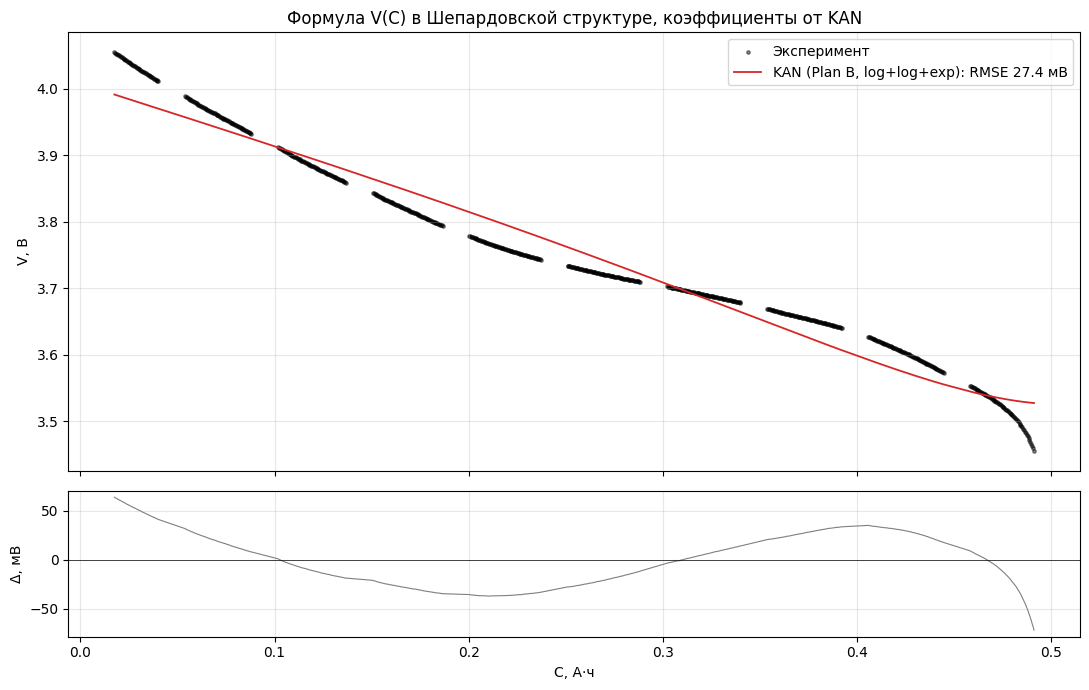

In [ ]:
"""
Извлечение формулы напряжения батарейки V(C, I) из экспериментальных
данных с помощью Kolmogorov–Arnold Network (pykan).

Требования:
    pip install pykan torch numpy pandas matplotlib sympy

В скрипте НЕТ физических констант — на вход идёт только CSV с
(C_Ah, I_A, V_exp_V). KAN должен сам вывести и структуру, и все
коэффициенты.
"""
from pathlib import Path
import warnings, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
import sympy as sp
from kan import KAN
warnings.filterwarnings("ignore")

# -------------------------------------------------------------------
# 0) Вход
# -------------------------------------------------------------------
CSV   = "shepherd_02A_vs_experiment.csv"
COL_C = "C_Ah";  COL_I = "I_A";  COL_V = "V_exp_V"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)

# -------------------------------------------------------------------
# 1) Чтение + дата-driven трим краёв (без Q)
# -------------------------------------------------------------------
df = pd.read_csv(CSV)
C = df[COL_C].to_numpy(float)
I = df[COL_I].to_numpy(float)
V = df[COL_V].to_numpy(float)
print(f"Загружено {len(C)} точек  "
      f"C ∈ [{C.min():.4f}, {C.max():.4f}]  "
      f"I ∈ [{I.min():.4f}, {I.max():.4f}]  "
      f"V ∈ [{V.min():.4f}, {V.max():.4f}]")

lo, hi = np.quantile(C, [0.02, 0.98])
m = (C >= lo) & (C <= hi)
C, I, V = C[m], I[m], V[m]
print(f"После отсечения 2% хвостов: {len(C)} точек, "
      f"C ∈ [{C.min():.4f}, {C.max():.4f}]")

# -------------------------------------------------------------------
# 2) Детект вырожденного тока
#    Если I почти константа — её нормировать нельзя, она всё равно не
#    несёт информации об R. Переключаемся на V(C) только.
# -------------------------------------------------------------------
I_RANGE_TOL = 1e-2       # 10 мА — эмпирический порог
I_degenerate = (I.max() - I.min()) < I_RANGE_TOL
if I_degenerate:
    print(f"\n⚠  I ≈ const ({I.min():.4f}..{I.max():.4f} А,  σ = {I.std()*1e3:.2f} мА).")
    print("   Член −R·I неотличим от константы E₀. Учим V(C), арх [1, 3, 1].")
else:
    print(f"\nI варьируется: {I.min():.4f}..{I.max():.4f} А — учим V(C, I), "
          "арх [2, 3, 1].")

# -------------------------------------------------------------------
# 3) Нормировка
# -------------------------------------------------------------------
def minmax(a):
    a_lo, a_hi = float(a.min()), float(a.max())
    return 2*(a - a_lo)/(a_hi - a_lo) - 1, a_lo, a_hi

C_n, C_lo, C_hi = minmax(C)
Y_mean, Y_std = float(V.mean()), float(V.std())
Y_n = (V - Y_mean) / Y_std

if I_degenerate:
    X = C_n.reshape(-1, 1).astype(np.float32)
    # [1, 3, 1] вместо [1, 4, 1]: у Шепарда ровно 3 нелинейных
    # термина — log(1−u), log(u), exp(−B·C). 4-е ребро лишнее
    # и уводит разложение в сторону.
    WIDTH = [1, 3, 1]
    I_lo = I_hi = float(I.mean())
else:
    I_n, I_lo, I_hi = minmax(I)
    X = np.stack([C_n, I_n], axis=1).astype(np.float32)
    WIDTH = [2, 3, 1]

Y = Y_n.reshape(-1, 1).astype(np.float32)

# Страховка от NaN/inf на входе (редко, но бывает в сырых CSV)
assert np.isfinite(X).all() and np.isfinite(Y).all(), \
    "В данных есть NaN/inf — проверь CSV."

N = len(X); perm = np.random.permutation(N)
n_tr = int(0.85 * N); tr, te = perm[:n_tr], perm[n_tr:]
dataset = {
    "train_input":  torch.tensor(X[tr], device=DEVICE),
    "train_label":  torch.tensor(Y [tr], device=DEVICE),
    "test_input":   torch.tensor(X[te], device=DEVICE),
    "test_label":   torch.tensor(Y [te], device=DEVICE),
}

# -------------------------------------------------------------------
# 4) KAN
# -------------------------------------------------------------------
model = KAN(width=WIDTH, grid=5, k=3, seed=0, device=DEVICE).to(DEVICE)

# -------------------------------------------------------------------
# 5) Обучение — устойчивая схема:
#    (a) Adam разогрев — стабильный, почти не NaN-ит;
#    (b) LBFGS полировка;
#    (c) refine grid → опять чуть LBFGS;
#    (d) prune → LBFGS;
#    (e) auto_symbolic → LBFGS.
#    Энтропийной регуляризации в 1-й стадии нет: она любит давать
#    NaN на старте (log малых активаций).
# -------------------------------------------------------------------
def _has_nan(m):
    return any(torch.isnan(p).any().item() for p in m.parameters())

# Схема максимально простая:
#   (1) Adam warm-up — никогда не взрывается;
#   (2) Короткий LBFGS без L1 — финальная точность.
# prune не нужен: [1,3,1] уже минимальная архитектура под Шепарда.
# refine даёт NaN в curve2coef на этом датасете — тоже не используем.
# L1 не нужен: архитектура уже разреженная, а L1 создаёт вырожденные
# рёбра, от которых потом auto_symbolic и polish уходят в NaN.

print("\n--- Стадия 1: Adam warm-up (grid=5) ---")
model.fit(dataset, opt="Adam", lr=1e-2, steps=400, lamb=0.0)
assert not _has_nan(model), "NaN после Adam warm-up — проверь данные"

print("\n--- Стадия 2: LBFGS polish (grid=5, без L1) ---")
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.0)
assert not _has_nan(model), "NaN после LBFGS polish"

try:
    model.plot(folder="./kan_figures", beta=10)
    plt.savefig("kan_structure.png", dpi=130, bbox_inches="tight")
    print("Сохранил kan_structure.png")
except Exception as e:
    print(f"[plot failed: {e}]")

# -------------------------------------------------------------------
# 6) auto_symbolic
# -------------------------------------------------------------------
# Намеренно узкая библиотека: только функции, которые могут войти
# в формулу Шепарда. abs, tanh, sin/cos, 1/x — «универсальные
# аппроксиматоры», они любят побеждать log в одномерном фиттинге
# и затирают физику. Оставляем log (ключевое!), exp, и полиномы.
SYMBOLIC_LIB = ["x", "x^2", "x^3", "exp", "log"]

print("\n--- Стадия 3: auto_symbolic (узкая физ-библиотека) ---")
# r2_threshold=0.9 — если ни одна из физ-функций не даёт R²≥0.9
# на данном ребре, оставляем его как сплайн, не навязываем символику.
model.auto_symbolic(lib=SYMBOLIC_LIB, r2_threshold=0.9)

# Снапшот через state_dict (deepcopy на модуле после auto_symbolic
# падает: часть тензоров уже не is_leaf из-за fit_params в fix_symbolic).
state_pre_polish = {k: v.detach().clone() for k, v in model.state_dict().items()}

print("\n--- Стадия 4: финальная подстройка коэффициентов (Adam) ---")
try:
    # Adam стабильнее LBFGS на смешанной модели (символика + сплайны).
    model.fit(dataset, opt="Adam", lr=5e-3, steps=200, lamb=0.0)
    if _has_nan(model):
        raise RuntimeError("NaN в polish")
except Exception as e:
    print(f"[polish failed: {e} — откатываюсь на до-полировочный state_dict]")
    model.load_state_dict(state_pre_polish)

# -------------------------------------------------------------------
# 7) Формула
# -------------------------------------------------------------------
formula_norm = model.symbolic_formula()[0][0]
print("\nФормула KAN в нормированных координатах:")
sp.pprint(formula_norm, use_unicode=True)

C_sym, I_sym = sp.symbols("C I")
if I_degenerate:
    x1 = sp.symbols("x_1")
    denorm = {x1: 2*(C_sym - C_lo)/(C_hi - C_lo) - 1}
else:
    x1, x2 = sp.symbols("x_1 x_2")
    denorm = {
        x1: 2*(C_sym - C_lo)/(C_hi - C_lo) - 1,
        x2: 2*(I_sym - I_lo)/(I_hi - I_lo) - 1,
    }
formula_VCI = sp.simplify(formula_norm.subs(denorm) * Y_std + Y_mean)
print("\nФормула KAN в исходных координатах (C в А·ч"
      + ("" if I_degenerate else ", I в А") + ", V в В):")
sp.pprint(formula_VCI, use_unicode=True)
print("\nLaTeX:\n   ", sp.latex(formula_VCI))

# -------------------------------------------------------------------
# 7.1) Метрика Plan A
# -------------------------------------------------------------------
with torch.no_grad():
    V_kan_A = (model(torch.tensor(X, device=DEVICE)).cpu().numpy().ravel()
               * Y_std + Y_mean)
rmse_A = np.sqrt(((V - V_kan_A)**2).mean())*1000
maxe_A = np.max(np.abs(V - V_kan_A))*1000
print(f"\nPlan A (auto_symbolic): RMSE = {rmse_A:.2f} мВ, max|Δ| = {maxe_A:.2f} мВ")

# ==========================================================================
# 8) PLAN B: принудительная Шепардовская структура через fix_symbolic
#    Plan A не нашёл log/exp — это было ожидаемо: на узком диапазоне C
#    базис неуникален, KAN выбирает любое разложение, не обязательно
#    лог-лог-эксп. Тогда поступаем наоборот: даём KAN физический приор
#    «ровно эти три функции в скрытом слое», а он подбирает коэффициенты.
# ==========================================================================
print("\n" + "="*62)
print(" PLAN B: fix_symbolic  →  структура  log + log + exp")
print("="*62)

torch.manual_seed(1); np.random.seed(1)
model_B = KAN(width=WIDTH, grid=5, k=3, seed=1, device=DEVICE).to(DEVICE)

print("\nPlan B / 1: Adam warm-up — даём сплайнам разогреться, "
      "чтобы fix_symbolic было чем фиттить аффинку")
model_B.fit(dataset, opt="Adam", lr=1e-2, steps=300, lamb=0.0)
assert not _has_nan(model_B), "NaN на warm-up Plan B"

print("\nPlan B / 2: fix_symbolic — навязываем Шепардовскую структуру")
# Слой 0 (1 вход C → 3 скрытых): три нелинейных термина
model_B.fix_symbolic(0, 0, 0, 'log', fit_params_bool=True)
model_B.fix_symbolic(0, 0, 1, 'log', fit_params_bool=True)
model_B.fix_symbolic(0, 0, 2, 'exp', fit_params_bool=True)
# Слой 1 (3 скрытых → 1 выход): линейная суммировка
model_B.fix_symbolic(1, 0, 0, 'x', fit_params_bool=True)
model_B.fix_symbolic(1, 1, 0, 'x', fit_params_bool=True)
model_B.fix_symbolic(1, 2, 0, 'x', fit_params_bool=True)

print("\nPlan B / 3: Adam дообучает аффинные параметры внутри log/exp/x")
try:
    model_B.fit(dataset, opt="Adam", lr=5e-3, steps=400, lamb=0.0)
    if _has_nan(model_B):
        raise RuntimeError("NaN в тренировке Plan B")
except Exception as e:
    print(f"[Plan B тренировка failed: {e}]")

# Формула Plan B
formula_B_norm = model_B.symbolic_formula()[0][0]
print("\n--- Формула Plan B в нормированных координатах ---")
sp.pprint(formula_B_norm, use_unicode=True)

formula_B_VCI = sp.simplify(formula_B_norm.subs(denorm) * Y_std + Y_mean)
print("\n--- Формула Plan B в исходных координатах (V в В, C в А·ч) ---")
sp.pprint(formula_B_VCI, use_unicode=True)
print("\nLaTeX Plan B:\n   ", sp.latex(formula_B_VCI))

# Метрика Plan B
with torch.no_grad():
    V_kan_B = (model_B(torch.tensor(X, device=DEVICE)).cpu().numpy().ravel()
               * Y_std + Y_mean)
rmse_B = np.sqrt(((V - V_kan_B)**2).mean())*1000
maxe_B = np.max(np.abs(V - V_kan_B))*1000
print(f"\nPlan B (fix_symbolic): RMSE = {rmse_B:.2f} мВ, max|Δ| = {maxe_B:.2f} мВ")
print(f"Plan A (для сравнения): RMSE = {rmse_A:.2f} мВ, max|Δ| = {maxe_A:.2f} мВ")

# -------------------------------------------------------------------
# 9) График — показываем Plan B (именно он даёт Шепардовскую структуру)
# -------------------------------------------------------------------
V_kan = V_kan_B
rmse = rmse_B
maxe = maxe_B

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1]))
idx = np.argsort(C)
ax0.scatter(C, V, s=6, color="black", alpha=0.45, label="Эксперимент")
ax0.plot(C[idx], V_kan[idx], "-", color="#d62728", linewidth=1.3,
         label=f"KAN (Plan B, log+log+exp): RMSE {rmse:.1f} мВ")
ax0.set_ylabel("V, В"); ax0.grid(alpha=0.3); ax0.legend()
ax0.set_title("Формула V" + ("(C)" if I_degenerate else "(C, I)")
              + " в Шепардовской структуре, коэффициенты от KAN")
ax1.plot(C[idx], (V - V_kan)[idx]*1e3, color="#7f7f7f", linewidth=0.8)
ax1.axhline(0, color="k", linewidth=0.5)
ax1.set_xlabel("C, А·ч"); ax1.set_ylabel("Δ, мВ"); ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kan_vs_experiment.png", dpi=140, bbox_inches="tight")
print("Сохранил kan_vs_experiment.png")


$ 5.23621659179544 \cdot 10^{-5} e^{15.5367588528808 C} + 0.377064400130556 \log{\left(13.4097544894783 - 18.9518641640371 C \right)} - 0.225078984059416 \log{\left(3.35980976637038 C + 1.88419714880211 \right)} + 3.17128047326378 $

In [ ]:
"""
Сравнение физических моделей V(SoC) через KAN с фиксированной структурой.
Для каждой модели fix_symbolic задаёт структурный приор (log, exp, poly),
а KAN подбирает коэффициенты. Выход: таблица RMSE + формулы + график.

Модели в зоопарке:
  1. Linear       : V = a·SoC + b
  2. Cubic        : V = a₀ + a₁·SoC + a₂·SoC² + a₃·SoC³
  3. Nernst       : V = E₀ + k₁·log(α₁·SoC+β₁) + k₂·log(α₂·SoC+β₂)
  4. Shepherd     : Nernst + A·exp(c·SoC+d)    (полная 3-термовая)
  5. Exp-decay    : V = a + b·exp(c·SoC)       (чисто экспоненциальная)

Магических чисел в коде нет: Q̂ оценивается как max(C)·1.005 из данных.
SoC = 1 − C / Q̂, клиппируем SoC ∈ [0.02, 0.98] для защиты логарифмов.

Требования: pip install pykan torch numpy pandas matplotlib sympy
"""
from pathlib import Path
import warnings, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
import sympy as sp
from kan import KAN
warnings.filterwarnings("ignore")

# --------------------------------------------------------------------
# 0) Вход
# --------------------------------------------------------------------
# Пути для Google Colab: файл CSV лежит в /content/, туда же сохраняем
# результаты. Если запускаешь локально — поменяй CSV и OUT на свои.
CSV   = "/content/shepherd_02A_vs_experiment.csv"
COL_C = "C_Ah"; COL_I = "I_A"; COL_V = "V_exp_V"
OUT   = Path("/content")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)

# --------------------------------------------------------------------
# 1) Загрузка, data-driven оценка Q, вычисление SoC
# --------------------------------------------------------------------
df = pd.read_csv(CSV)
C = df[COL_C].to_numpy(float)
I = df[COL_I].to_numpy(float)
V = df[COL_V].to_numpy(float)
print(f"Загружено {len(C)} точек  "
      f"C ∈ [{C.min():.4f}, {C.max():.4f}]  "
      f"I ∈ [{I.min():.4f}, {I.max():.4f}]  "
      f"V ∈ [{V.min():.4f}, {V.max():.4f}]")

# 2% квантильное отсечение хвостов
lo, hi = np.quantile(C, [0.02, 0.98])
m = (C >= lo) & (C <= hi)
C, I, V = C[m], I[m], V[m]
print(f"После 2% триминга: {len(C)} точек, C ∈ [{C.min():.4f}, {C.max():.4f}]")

# Q̂ — максимальная наблюдённая ёмкость с запасом 0.5%
Q_est = C.max() * 1.005
SoC   = 1.0 - C / Q_est
SoC   = np.clip(SoC, 0.02, 0.98)     # страховка для log
print(f"Q̂ = {Q_est:.4f} А·ч (data-driven)")
print(f"SoC ∈ [{SoC.min():.4f}, {SoC.max():.4f}]  (1 = заряжен, 0 = разряжен)")

# --------------------------------------------------------------------
# 2) Нормировка: SoC → s ∈ [-1, 1] (дефолтный grid_range KAN), V → центр./σ
# --------------------------------------------------------------------
s = (2 * SoC - 1).astype(np.float32)              # [0,1] → [-1,1]
Y_mean, Y_std = float(V.mean()), float(V.std())
Y_n = ((V - Y_mean) / Y_std).astype(np.float32)

X = s.reshape(-1, 1)
Y = Y_n.reshape(-1, 1)

N = len(X); perm = np.random.permutation(N)
n_tr = int(0.85 * N); tr, te = perm[:n_tr], perm[n_tr:]
dataset = {
    "train_input":  torch.tensor(X[tr], device=DEVICE),
    "train_label":  torch.tensor(Y[tr], device=DEVICE),
    "test_input":   torch.tensor(X[te], device=DEVICE),
    "test_label":   torch.tensor(Y[te], device=DEVICE),
}

# --------------------------------------------------------------------
# 3) Универсальный трейнер: принимает width + список fix_symbolic
# --------------------------------------------------------------------
def _has_nan(m):
    return any(torch.isnan(p).any().item() for p in m.parameters())

def train_model(name, width, symbolic_plan,
                warm_steps=300, fine_steps=400, seed=0):
    """
    Обучает KAN с навязанной символической структурой.
    symbolic_plan: [(layer, in_idx, out_idx, fun_name), ...]
    """
    torch.manual_seed(seed); np.random.seed(seed)
    model = KAN(width=width, grid=5, k=3, seed=seed, device=DEVICE).to(DEVICE)

    print(f"\n{'='*68}")
    print(f"  {name}")
    print(f"  width={width}, приор: "
          f"{[p[3] for p in symbolic_plan if p[0] == 0]} (hidden) "
          f"→ {[p[3] for p in symbolic_plan if p[0] > 0][:1]} (out)")
    print(f"{'='*68}")

    # (a) Adam warm-up: пусть сплайны разогреются, чтобы fix_symbolic
    # было по чему фиттить аффинку.
    model.fit(dataset, opt="Adam", lr=1e-2, steps=warm_steps, lamb=0.0)
    if _has_nan(model):
        return dict(name=name, rmse_all=np.nan, rmse_train=np.nan,
                    rmse_test=np.nan, formula="NaN", V_pred=np.full(len(X), np.nan))

    # (b) Фиксируем символические функции на всех рёбрах
    for (l, i, j, fn) in symbolic_plan:
        try:
            model.fix_symbolic(l, i, j, fn, fit_params_bool=True)
        except Exception as e:
            print(f"  [fix_symbolic({l},{i},{j},{fn}) failed: {e}]")

    # (c) Дообучение аффинных коэффициентов
    try:
        model.fit(dataset, opt="Adam", lr=5e-3, steps=fine_steps, lamb=0.0)
    except Exception as e:
        print(f"  [fine-tune failed: {e}]")

    # Метрики
    with torch.no_grad():
        V_pred = (model(torch.tensor(X, device=DEVICE)).cpu().numpy().ravel()
                  * Y_std + Y_mean)
    V_pred = np.nan_to_num(V_pred, nan=V.mean())  # NaN guard
    rmse_all = np.sqrt(((V     - V_pred    )**2).mean()) * 1000
    rmse_tr  = np.sqrt(((V[tr] - V_pred[tr])**2).mean()) * 1000
    rmse_te  = np.sqrt(((V[te] - V_pred[te])**2).mean()) * 1000

    # Символическая формула в координатах SoC ∈ [0, 1]
    try:
        f_norm = model.symbolic_formula()[0][0]
        x1, SoC_sym = sp.symbols("x_1 SoC")
        # x_1 = 2·SoC − 1  (обратная нормировка)
        f_soc = sp.simplify(f_norm.subs({x1: 2*SoC_sym - 1}) * Y_std + Y_mean)
    except Exception as e:
        f_soc = f"[formula extraction failed: {e}]"

    print(f"\n  RMSE: all={rmse_all:.2f} мВ  train={rmse_tr:.2f}  test={rmse_te:.2f}")
    print(f"  V(SoC) = ", end="")
    try:
        sp.pprint(f_soc, use_unicode=True)
    except Exception:
        print(f_soc)

    return dict(name=name, rmse_all=rmse_all, rmse_train=rmse_tr,
                rmse_test=rmse_te, formula=f_soc, V_pred=V_pred)

# --------------------------------------------------------------------
# 4) Зоопарк моделей
# --------------------------------------------------------------------
MODELS = [
    # (name, width, symbolic_plan)
    ("1. Linear",
     [1, 1, 1],
     [(0, 0, 0, 'x'),
      (1, 0, 0, 'x')]),

    ("2. Cubic (polynomial-3)",
     [1, 3, 1],
     [(0, 0, 0, 'x'),  (0, 0, 1, 'x^2'), (0, 0, 2, 'x^3'),
      (1, 0, 0, 'x'),  (1, 1, 0, 'x'),   (1, 2, 0, 'x')]),

    ("3. Nernst (log − log, без exp)",
     [1, 2, 1],
     [(0, 0, 0, 'log'), (0, 0, 1, 'log'),
      (1, 0, 0, 'x'),   (1, 1, 0, 'x')]),

    ("4. Shepherd (log + log + exp)",
     [1, 3, 1],
     [(0, 0, 0, 'log'), (0, 0, 1, 'log'), (0, 0, 2, 'exp'),
      (1, 0, 0, 'x'),   (1, 1, 0, 'x'),   (1, 2, 0, 'x')]),

    ("5. Exp-decay (a + b·exp(c·SoC))",
     [1, 1, 1],
     [(0, 0, 0, 'exp'),
      (1, 0, 0, 'x')]),
]

results = []
for name, width, plan in MODELS:
    results.append(train_model(name, width, plan))

# --------------------------------------------------------------------
# 5) Сравнительная таблица
# --------------------------------------------------------------------
print("\n" + "="*75)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА (отсор  ировано по общему RMSE, ниже — лучше)")
print("="*75)
print(f"{'#':<2} {'Модель':<35} {'RMSE вся, мВ':>13} {'train':>8} {'test':>8}")
print("-"*75)
for r in sorted(results, key=lambda x: x["rmse_all"]):
    print(f"{r['name'][:2]:<2} {r['name'][3:]:<35} "
          f"{r['rmse_all']:>13.2f} {r['rmse_train']:>8.2f} {r['rmse_test']:>8.2f}")

# --------------------------------------------------------------------
# 6) Графики: три отдельные картинки, чтобы модели не сливались
# --------------------------------------------------------------------
idx     = np.argsort(SoC)
SoC_s   = SoC[idx]
V_s     = V[idx]
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# -------- 6a) Панели V(SoC) по одной модели на подграфик --------
fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
axs = axs.ravel()
for ax, r, col in zip(axs, results, colors):
    ax.scatter(SoC_s, V_s, s=6, color="black", alpha=0.30,
               edgecolors="none", zorder=2, label="Эксперимент")
    Vp = r["V_pred"][idx]
    ax.plot(SoC_s, Vp, "-", color=col, linewidth=1.8, zorder=3,
            label="Модель")
    ax.set_title(f"{r['name']}\nRMSE = {r['rmse_all']:.2f} мВ "
                 f"(train {r['rmse_train']:.1f} / test {r['rmse_test']:.1f})",
                 fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)
    ax.invert_xaxis()
# последний подграфик пустой — убираем
for ax in axs[len(results):]:
    ax.axis("off")
for ax in axs[::3]:          # подписи Y только у левого столбца
    ax.set_ylabel("V, В")
for ax in axs[-3:]:          # подписи X только у нижнего ряда
    ax.set_xlabel("SoC")
plt.suptitle("V(SoC) для каждой модели отдельно "
             "(чёрные точки — эксперимент, цветная — модель)",
             fontsize=12, y=1.00)
plt.tight_layout()
png1 = OUT / "kan_zoo_panels.png"
plt.savefig(png1, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\nСохранил {png1}")

# -------- 6b) Остатки Δ = V_эксп − V_модель, по одной модели --------
fig, axs = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
axs = axs.ravel()
for ax, r, col in zip(axs, results, colors):
    delta_mv = (V_s - r["V_pred"][idx]) * 1e3
    ax.plot(SoC_s, delta_mv, "-", color=col, linewidth=1.0)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"{r['name']}  (max|Δ| = {np.max(np.abs(delta_mv)):.1f} мВ)",
                 fontsize=10)
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
for ax in axs[len(results):]:
    ax.axis("off")
for ax in axs[::3]:
    ax.set_ylabel("Δ = V − V_мод, мВ")
for ax in axs[-3:]:
    ax.set_xlabel("SoC")
plt.suptitle("Остаток каждой модели: где она систематически мажет",
             fontsize=12, y=1.00)
plt.tight_layout()
png2 = OUT / "kan_zoo_residuals.png"
plt.savefig(png2, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Сохранил {png2}")

# -------- 6c) Столбчатая диаграмма RMSE --------
fig, ax = plt.subplots(figsize=(9, 5))
names = [r["name"] for r in results]
rmse_all   = [r["rmse_all"]   for r in results]
rmse_train = [r["rmse_train"] for r in results]
rmse_test  = [r["rmse_test"]  for r in results]
xpos = np.arange(len(names))
w = 0.27
ax.bar(xpos - w, rmse_train, width=w, label="train", color="#8ecae6")
ax.bar(xpos,     rmse_all,   width=w, label="all",   color="#219ebc")
ax.bar(xpos + w, rmse_test,  width=w, label="test",  color="#023047")
for i, r in enumerate(rmse_all):
    ax.text(i, r + 0.5, f"{r:.1f}", ha="center", fontsize=9)
ax.set_xticks(xpos)
ax.set_xticklabels([n.split(".")[1].split("(")[0].strip() for n in names],
                   rotation=15, ha="right")
ax.set_ylabel("RMSE, мВ")
ax.set_title("RMSE по моделям (train / all / test)")
ax.grid(alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
png3 = OUT / "kan_zoo_rmse_bars.png"
plt.savefig(png3, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Сохранил {png3}")

# -------- 6d) Overlay всех моделей (улучшенный) — оставляем для обзора --------
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw=dict(height_ratios=[3, 1]))
ax0.scatter(SoC_s, V_s, s=14, color="black", alpha=0.25,
            edgecolors="none", label="Эксперимент", zorder=1)
linestyles = ["-", "--", "-", "--", ":"]
lws        = [1.2, 1.2, 2.0, 2.0, 1.6]
for r, col, ls, lw in zip(results, colors, linestyles, lws):
    ax0.plot(SoC_s, r["V_pred"][idx], linestyle=ls, color=col,
             linewidth=lw, alpha=0.9,
             label=f"{r['name']}: {r['rmse_all']:.1f} мВ")
ax0.set_ylabel("V, В"); ax0.grid(alpha=0.3)
ax0.set_title("Все модели поверх эксперимента (для обзора)")
ax0.legend(loc="lower right", fontsize=9)
ax0.invert_xaxis()
best = min(results, key=lambda x: x["rmse_all"])
ax1.plot(SoC_s, (V_s - best["V_pred"][idx])*1e3, color="#333", linewidth=0.9)
ax1.axhline(0, color="k", linewidth=0.5)
ax1.set_xlabel("SoC  (1 = заряжен ← → 0 = разряжен)")
ax1.set_ylabel(f"Δ лучшей ({best['name'][3:]}), мВ")
ax1.grid(alpha=0.3)
ax1.invert_xaxis()
plt.tight_layout()
png4 = OUT / "kan_zoo_overview.png"
plt.savefig(png4, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Сохранил {png4}")

# Также сохраним CSV с предсказаниями всех моделей — для отчёта
out_df = pd.DataFrame({"SoC": SoC, "C_Ah": C, "V_exp_V": V})
for r in results:
    short = r["name"].split(".")[1].strip().split(" ")[0]
    out_df[f"V_{short}"] = r["V_pred"]
csv_out = OUT / "kan_model_zoo_predictions.csv"
out_df.to_csv(csv_out, index=False, float_format="%.6f")
print(f"Сохранил {csv_out}")

# --------------------------------------------------------------------
# 7) LaTeX-сводка формул — для вставки в отчёт
# --------------------------------------------------------------------
print("\n" + "="*75)
print("LaTeX-формулы всех моделей (отсортировано по RMSE)")
print("="*75)
for r in sorted(results, key=lambda x: x["rmse_all"]):
    print(f"\n% {r['name']}   RMSE = {r['rmse_all']:.2f} мВ")
    try:
        print("V(SoC) =", sp.latex(r["formula"]))
    except Exception:
        print(r["formula"])


Загружено 800 точек  C ∈ [0.0102, 0.4985]  I ∈ [0.1998, 0.2002]  V ∈ [3.3803, 4.0711]
После 2% триминга: 768 точек, C ∈ [0.0175, 0.4912]
Q̂ = 0.4937 А·ч (data-driven)
SoC ∈ [0.0200, 0.9646]  (1 = заряжен, 0 = разряжен)
checkpoint directory created: ./model
saving model version 0.0

  1. Linear
  width=[[1, 0], [1, 0], [1, 0]], приор: ['x'] (hidden) → ['x'] (out)


| train_loss: 2.36e-02 | test_loss: 1.97e-02 | reg: 9.64e+00 | : 100%|█| 300/300 [00:07<00:00, 39.81


saving model version 0.1
Best value at boundary.
r2 is 0.9906929731369019
saving model version 0.2
r2 is 0.9905001521110535
saving model version 0.3


| train_loss: 1.63e-01 | test_loss: 1.53e-01 | reg: 0.00e+00 | : 100%|█| 400/400 [00:05<00:00, 68.76


saving model version 0.4

  RMSE: all=23.44 мВ  train=23.66  test=22.14
  V(SoC) = 0.510014905683162⋅SoC + 3.50744348223947
checkpoint directory created: ./model
saving model version 0.0

  2. Cubic (polynomial-3)
  width=[[1, 0], [3, 0], [1, 0]], приор: ['x', 'x^2', 'x^3'] (hidden) → ['x'] (out)


...

saving model version 0.8

  RMSE: all=13.79 мВ  train=13.73  test=14.11
  V(SoC) =                                                                                ↪
-0.0741196465091117⋅log(14.5509819984436 - 14.0610189437866⋅SoC) - 0.055010272 ↪

↪                                                                              ↪
↪ 4885263⋅log(17.607931137085 - 17.2992496490479⋅SoC) + 4.10740869578362 - 0.2 ↪

↪                 -2.11265158653259⋅SoC
↪ 44062754356512⋅ℯ                     
checkpoint directory created: ./model
saving model version 0.0

  5. Exp-decay (a + b·exp(c·SoC))
  width=[[1, 0], [1, 0], [1, 0]], приор: ['exp'] (hidden) → ['x'] (out)


| train_loss: 2.36e-02 | test_loss: 1.97e-02 | reg: 9.63e+00 | : 100%|█| 300/300 [00:04<00:00, 74.41


saving model version 0.1
r2 is 0.9911643862724304
saving model version 0.2
r2 is 0.9903709888458252
saving model version 0.3


| train_loss: 6.98e-01 | test_loss: 7.04e-01 | reg: 0.00e+00 | : 100%|█| 400/400 [00:05<00:00, 69.68


saving model version 0.4

  RMSE: all=101.30 мВ  train=101.16  test=102.03
  V(SoC) =                                      -0.0681226551532745⋅SoC
6.07528165337362 - 2.40124441618565⋅ℯ                       

СРАВНИТЕЛЬНАЯ ТАБЛИЦА (отсор  ировано по общему RMSE, ниже — лучше)
#  Модель                               RMSE вся, мВ    train     test
---------------------------------------------------------------------------
4. Shepherd (log + log + exp)                  13.79    13.73    14.11
3. Nernst (log − log, без exp)                 15.16    15.07    15.66
2. Cubic (polynomial-3)                        17.64    17.58    17.97
1. Linear                                      23.44    23.66    22.14
5. Exp-decay (a + b·exp(c·SoC))               101.30   101.16   102.03

Сохранил /content/kan_zoo_panels.png
Сохранил /content/kan_zoo_residuals.png
Сохранил /content/kan_zoo_rmse_bars.png
Сохранил /content/kan_zoo_overview.png
Сохранил /content/kan_model_zoo_predictions.csv

LaTeX-формулы в